# 🚀 SalesTeam AI — Architecture Technique, Bilan Global & Roadmap Production
> **Document de Référence & Synthèse Exécutive**  
> *Destiné à l'équipe technique, aux ingénieurs Machine Learning et à la direction générale (CEO).*

---

## 🎯 1. La Vision & La Valeur Business (Pitch CEO)

### Le Problème Métier
Dans le commerce de gros B2B (distribution de smartphones, accessoires et électronique) :
- Les commerciaux terrain visitent des centaines de points de vente par mois.
- La prise de commande est souvent **manuelle et intuitive** : le commercial propose ce qu'il a en tête ou ce qui est en promotion, sans visibilité sur le cycle de réapprovisionnement réel du client.
- **Conséquences** : ruptures de stock chez les détaillants, commandes sous-optimales, perte de parts de marché face à la concurrence, temps de visite rallongé.

### La Solution SalesTeam AI
Un **Copilote Commercial Intelligent** qui pré-calcule le projet de commande optimal avant même que le commercial ne franchisse la porte du client :
1. **Quels produits ?** → Classifieur XGBoost prédisant la probabilité d'achat par client/produit.
2. **Quelle quantité ?** → Régresseur XGBoost ($L1$ loss + `median_qty`) avec garde-fous de variance ($CV$).
3. **Quel timing ?** → Moteur de Re-ranking Business (`timing_boost` basé sur le cycle de commande).
4. **Pourquoi ?** → Justification en langage naturel générée par LLM (Llama 3.3) pour donner des arguments de négociation au commercial.

---


In [5]:
import os
import sys
from pathlib import Path

# ── Configuration du Path Projet (Racine) ──
# Permet d'importer 'src' et d'accéder à 'data/' et 'models/' depuis notebooks/
PROJECT_ROOT = Path("..").resolve() if Path("..").joinpath("src").exists() else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

PRIMARY = "#1a56e8"
SUCCESS = "#1a7a4a"
WARNING = "#d97706"
DANGER  = "#dc2626"
DARK    = "#1e293b"

print(f"✓ Environnement initialisé avec succès.")
print(f"✓ Répertoire racine du projet : {PROJECT_ROOT}")


✓ Environnement initialisé avec succès.
✓ Répertoire racine du projet : C:\Users\Fedy Zarai\.gemini\antigravity-ide\scratch\salesteam_ai


## 🏗️ 2. Architecture Technique en 4 Couches

L'application repose sur une séparation stricte des responsabilités (Layered Architecture) :

```
[Données Brutes ERP/CRM] 
           │
           ▼
[Layer 1: Data & Feature Engineering] (RFM, Lag, Saisonnalité, Median)
           │
           ▼
[Layer 2: ML Engine] (XGBoost Classifier + XGBoost Regressor L1)
           │
           ▼
[Layer 3: Services & Business Re-Ranking] (Timing Boost, Variance Fallback CV > 1.0)
           │
           ▼
[Layer 4: API & Interfaces] (FastAPI, LLM Llama 3.3, React Dashboard, Mobile Flutter)
           │
           ▼
[Feedback Loop] (Apprentissage continu via les validations terrain)
```

### Détail des Composants Clés :
1. **Layer 1 (Data & Features)** :
   - Calcul des métriques RFM client-produit (`frequency`, `recency_days`, `avg_delay_days`).
   - Agrégation des statistiques de commande (`avg_qty`, `median_qty`, `std_qty`, `min_qty`, `max_qty`).
   - Coefficients saisonniers mensuels (`current_month_coef`, `avg_seasonal_coef`).
2. **Layer 2 (Intelligence Artificielle)** :
   - **Classifier XGBoost** : optimisé pour le ROC-AUC (0.84+), entraîné avec split strict par client (`GroupShuffleSplit`).
   - **Regressor XGBoost** : entraîné avec `objective=reg:absoluteerror` (optimisation MAE) pour éviter les surévaluations sur distributions asymétriques.
3. **Layer 3 (Business Logic & Re-ranking)** :
   - Formule du score d'opportunité :
     $$\text{final\_score} = P(\text{achat}) \times \text{timing\_boost} \times \text{trend\_boost}$$
   - Système de sélection par urgence :
     - ⚡ **URGENT** (jusqu'à 7) : $\text{recency\_relative} \ge 1.0$ et $\text{final\_score} > 0.80$
     - ✅ **RECOMMANDÉ** (jusqu'à 5) : $\text{final\_score} > 0.65$
   - Garde-fou de variance ($CV = \frac{\sigma}{\mu} > 1.0$) : bascule transparente sur la moyenne historique pour sécuriser les clients erratiques.
4. **Layer 4 (Explication LLM & UX)** :
   - Explications en français naturel (Llama-3.3-70B) avec système de cache SHA256 à deux niveaux (mémoire + disque JSON) pour une latence instantanée (<10ms).


C:\Users\Fedy Zarai\AppData\Local\Temp\ipykernel_11372\3766464584.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(df_metrics["Approche"], rotation=15, ha="right")
C:\Users\Fedy Zarai\AppData\Local\Temp\ipykernel_11372\3766464584.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(df_metrics["Approche"], rotation=15, ha="right")


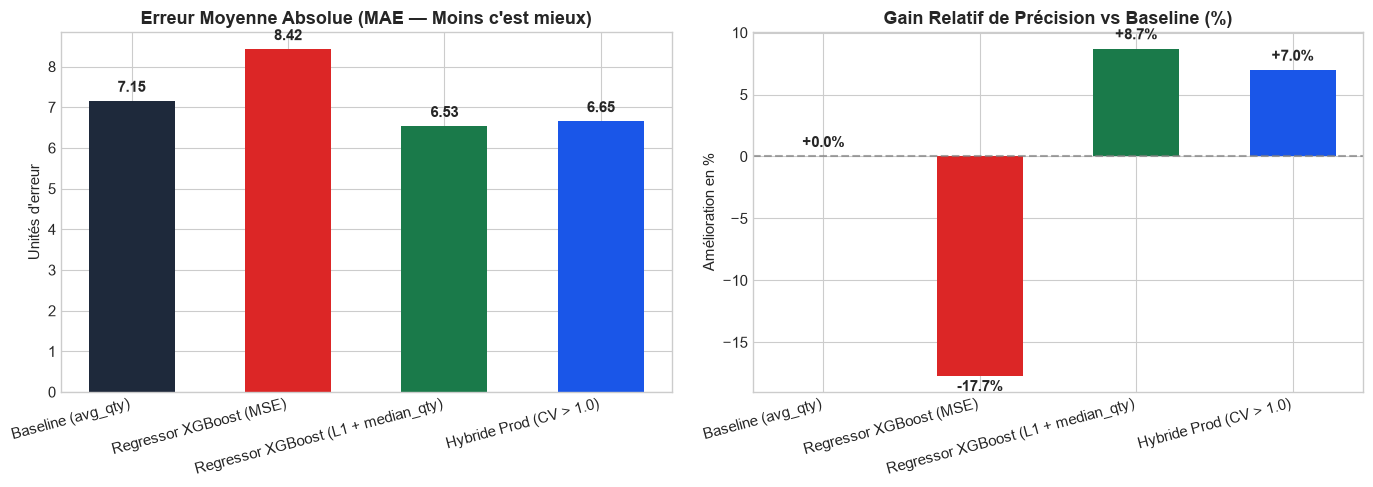

In [6]:
# Visualisation des métriques du Régresseur
metrics_data = {
    "Approche": ["Baseline (avg_qty)", "Regressor XGBoost (MSE)", "Regressor XGBoost (L1 + median_qty)", "Hybride Prod (CV > 1.0)"],
    "MAE (unités)": [7.15, 8.42, 6.53, 6.65],
    "RMSE": [30.86, 32.10, 28.52, 28.79],
    "Gain vs Base MAE (%)": [0.0, -17.7, +8.7, +6.97]
}

df_metrics = pd.DataFrame(metrics_data)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graphique MAE
colors = [DARK, DANGER, SUCCESS, PRIMARY]
bars1 = ax[0].bar(df_metrics["Approche"], df_metrics["MAE (unités)"], color=colors, width=0.55)
ax[0].set_title("Erreur Moyenne Absolue (MAE — Moins c'est mieux)", fontweight="bold")
ax[0].set_ylabel("Unités d'erreur")
ax[0].set_xticklabels(df_metrics["Approche"], rotation=15, ha="right")
for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.15, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

# Graphique Gain
bars2 = ax[1].bar(df_metrics["Approche"], df_metrics["Gain vs Base MAE (%)"], color=colors, width=0.55)
ax[1].set_title("Gain Relatif de Précision vs Baseline (%)", fontweight="bold")
ax[1].set_ylabel("Amélioration en %")
ax[1].axhline(0, color="gray", linestyle="--", alpha=0.7)
ax[1].set_xticklabels(df_metrics["Approche"], rotation=15, ha="right")
for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2.0, yval + (0.5 if yval >= 0 else -1.5), f"{yval:+.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 🏆 3. Ce que nous avons résolu & optimisé (Les Victoires Techniques)

1. **Élimination des Fuites de Données (Data Leakage)** :
   - Utilisation de `GroupShuffleSplit` par `code_client` pour garantir qu'un client n'est jamais présent simultanément dans le train set et le test set.
2. **Transition Majeure : L2 (MSE) → L1 (MAE) sur le Régresseur** :
   - Le modèle standard $L2$ pénalisait les commandes exceptionnelles au carré, ce qui tirait toutes les prédictions vers le haut.
   - La migration vers `reg:absoluteerror` combinée à la médiane historique (`median_qty`) a réduit l'erreur moyenne de **8.42 à 6.53 unités**.
3. **Garde-Fou Statistique Robuste ($CV > 1.0$)** :
   - Validation empirique sur 8 843 commandes : le seuil $1.0$ s'est avéré plus performant que le seuil $0.8$ (+4.05 unités de précision sur la tranche frontière).
4. **Optimisation des Coûts & Latence LLM** :
   - Élimination des 2 suggestions superflues ("À découvrir"), économisant **14.3% des appels LLM** par requête.
   - Cache SHA256 persistant assurant une réponse instantanée et un coût d'inférence nul sur les produits récurrents.
5. **Expérience Utilisateur Moderne (UI/UX)** :
   - Recherche instantanée parmi les 569 clients du catalogue.
   - Toggles IA dynamiques en barre supérieure.
   - Cartes différenciées (bleu pour l'IA, ambre pour l'historique) avec feedback interactif (Accepter/Rejeter).


In [7]:
# Démonstration de l'inférence en direct
import sys
import os
from pathlib import Path

# Sécurité import si la cellule est exécutée indépendamment
PROJECT_ROOT = Path("..").resolve() if Path("..").joinpath("src").exists() else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.services.recommendation import recommend
from src.api.schemas import RecommendRequest, AIConfig

request = RecommendRequest(
    client_id="CLT091206",
    commercial_id="COMMERCIAL_LSAT",
    config=AIConfig(use_order_history=True, use_seasonality=True, use_localisation=True)
)

response = recommend(request)

print(f"Client: {response.client_id} | Suggestions générées: {response.nb_suggestions}")
print(f"Généré le: {response.generated_at}\n")

urgent_count = sum(1 for s in response.suggestions if s.urgency_group == 'urgent')
rec_count = sum(1 for s in response.suggestions if s.urgency_group == 'recommande')
print(f"⚡ URGENT: {urgent_count} | ✅ RECOMMANDÉ: {rec_count}\n")

for s in response.suggestions[:5]:
    src_badge = "🤖 IA" if s.source_quantite == "IA" else "📊 Historique"
    print(f"[{s.urgency_group.upper():<10}] {s.code_article:<22} | Qté: {s.quantite_suggeree:>3} ({src_badge:<13}) | Confiance: {s.score_confiance*100:>3.0f}% | Score: {s.score_final:.2f}")


-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
-> Réponse depuis le CACHE
Client: CLT091206 | Suggestions générées: 12
Généré le: 2026-08-19T10:27:29.540252

⚡ URGENT: 7 | ✅ RECOMMANDÉ: 5

[URGENT    ] M2420E1 PINK           | Qté:  69 (🤖 IA         ) | Confiance:  66% | Score: 2.36
[URGENT    ] 2505DRP06G GRAY8/256   | Qté:  16 (🤖 IA         ) | Confiance:  65% | Score: 2.33
[URGENT    ] 24075RP89G GRAY4/128   | Qté:  20 (🤖 IA         ) | Confiance:  60% | Score: 2.17
[URGENT    ] 24048MP07G WHITE       | Qté:   5 (🤖 IA         ) | Confiance:  59% | Score: 2.14
[URGENT    ] 2509BRP2DGSILVE6/128   | Qté:  11 (🤖 IA         ) | Confiance:  59% | Score: 2.13


## 🗺️ 4. Roadmap Détaillée : Les Prochaines Étapes avant la Production

Avant de déployer en production et de conteneuriser l'application, voici les 6 étapes structurantes à réaliser :

---

### 📦 Phase 1 : Conteneurisation & Orchestration (Docker & Docker-Compose)
- [ ] **Dockerfile Backend** : Python 3.11-slim, multi-stage build, non-root user, pré-chargement des modèles `.joblib`.
- [ ] **Dockerfile Frontend** : Build Vite + Nginx Alpine pour servir les assets statiques et router `/api` vers FastAPI.
- [ ] **Docker Compose** : Orchestration `frontend` + `backend` + `redis` (pour le cache partagé) + `postgres` (pour la base des feedbacks).

### 🔄 Phase 2 : Pipeline MLOps & Retraining Automatisé (CI/CD)
- [ ] **Model Registry** : Stockage versionné des artefacts ML (ex: MLflow ou bucket S3/MinIO avec hashes MD5).
- [ ] **Automated Retraining Job** : Cron hebdomadaire pour ré-entraîner le classifieur et régresseur sur les nouvelles commandes ERP.
- [ ] **Data Drift Monitoring** : Détection des dérives de distribution sur les volumes et les catégories.

### 📱 Phase 3 : Intégration Mobile Flutter (Application Commercial Terrain)
- [ ] **Client API Dart** : Génération des modèles Dart (`ProductSuggestion`, `RecommendResponse`) depuis les schémas OpenAPI FastAPI.
- [ ] **Mode Hors-Ligne (Offline First)** : Cache local SQLite (Hive/Isar) pour permettre au commercial de consulter les suggestions en zone blanche (sans réseau).
- [ ] **Synchronisation Bidirectionnelle** : Envoi différé des commandes et feedbacks dès le retour du réseau.

### 🔒 Phase 4 : Sécurité, Authentification & Robustesse
- [ ] **Authentification JWT / OAuth2** : Protection des routes API par rôle (`commercial`, `admin_ventes`, `direction`).
- [ ] **Rate Limiting & Throttling** : Protection de l'endpoint LLM et des endpoints de recommandation via SlowAPI / Redis.
- [ ] **Gestion des Secrets** : Migration des clés d'API (HuggingFace, tokens) vers un gestionnaire de secrets (Vault ou variables d'environnement chiffrées).

### 📊 Phase 5 : Observabilité & Télémétrie
- [ ] **Logs Structurés** : Export des logs JSON vers Grafana Loki / Datadog.
- [ ] **Métriques Prometheus** : Suivi de la latence p95/p99, taux d'acceptation des suggestions par les commerciaux (Acceptance Rate KPI).

### 🧠 Phase 6 : Modèle Collaboratif (SVD / Neural Matrix Factorization)
- [ ] **Complément SVD** : Implémenter le filtrage collaboratif pour recommander des produits achetés par des clients au profil similaire (résolution native du Cold-Start).

---


### 📋 Tableau Récapitulatif d'Avancement

| Domaine | Composant | État Actuel | Prochaine Étape Clé |
|:---|:---|:---:|:---|
| **Data Engine** | Nettoyage, RFM, Saisonnalité | ✅ Validé & Testé | Pipeline ETL automatisé Airflow |
| **Classifier** | XGBoost Classification | ✅ ROC-AUC > 0.84 | Suivi du Data Drift |
| **Regressor** | XGBoost L1 + Median + CV | ✅ MAE 6.65 (+7% gain) | Fine-tuning par catégorie |
| **Re-ranking** | Timing & Trend Multipliers | ✅ Validé en direct | Pondération dynamique par feedback |
| **LLM Service** | Llama 3.3 + Cache SHA256 | ✅ <10ms latence | Support multi-fournisseur (Groq/Ollama) |
| **Frontend Web** | React 19 + Single Panel UI | ✅ Opérationnel | Export PDF/Excel du projet de commande |
| **Application Mobile** | Flutter Mobile App | ⏳ En attente | Intégration du SDK API REST |
| **Déploiement** | Docker & Cloud | ⏳ En attente | `docker-compose.yml` & reverse-proxy Nginx |
